# Check RNA-seq sample quality

Motivation: It appears that for the second replicate there is an anomolous sample for many genes.

Show that for the RNA-seq replicate 2 bam file, the 70 minute timepoint should be dropped in deconvolution analysis.


In [18]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


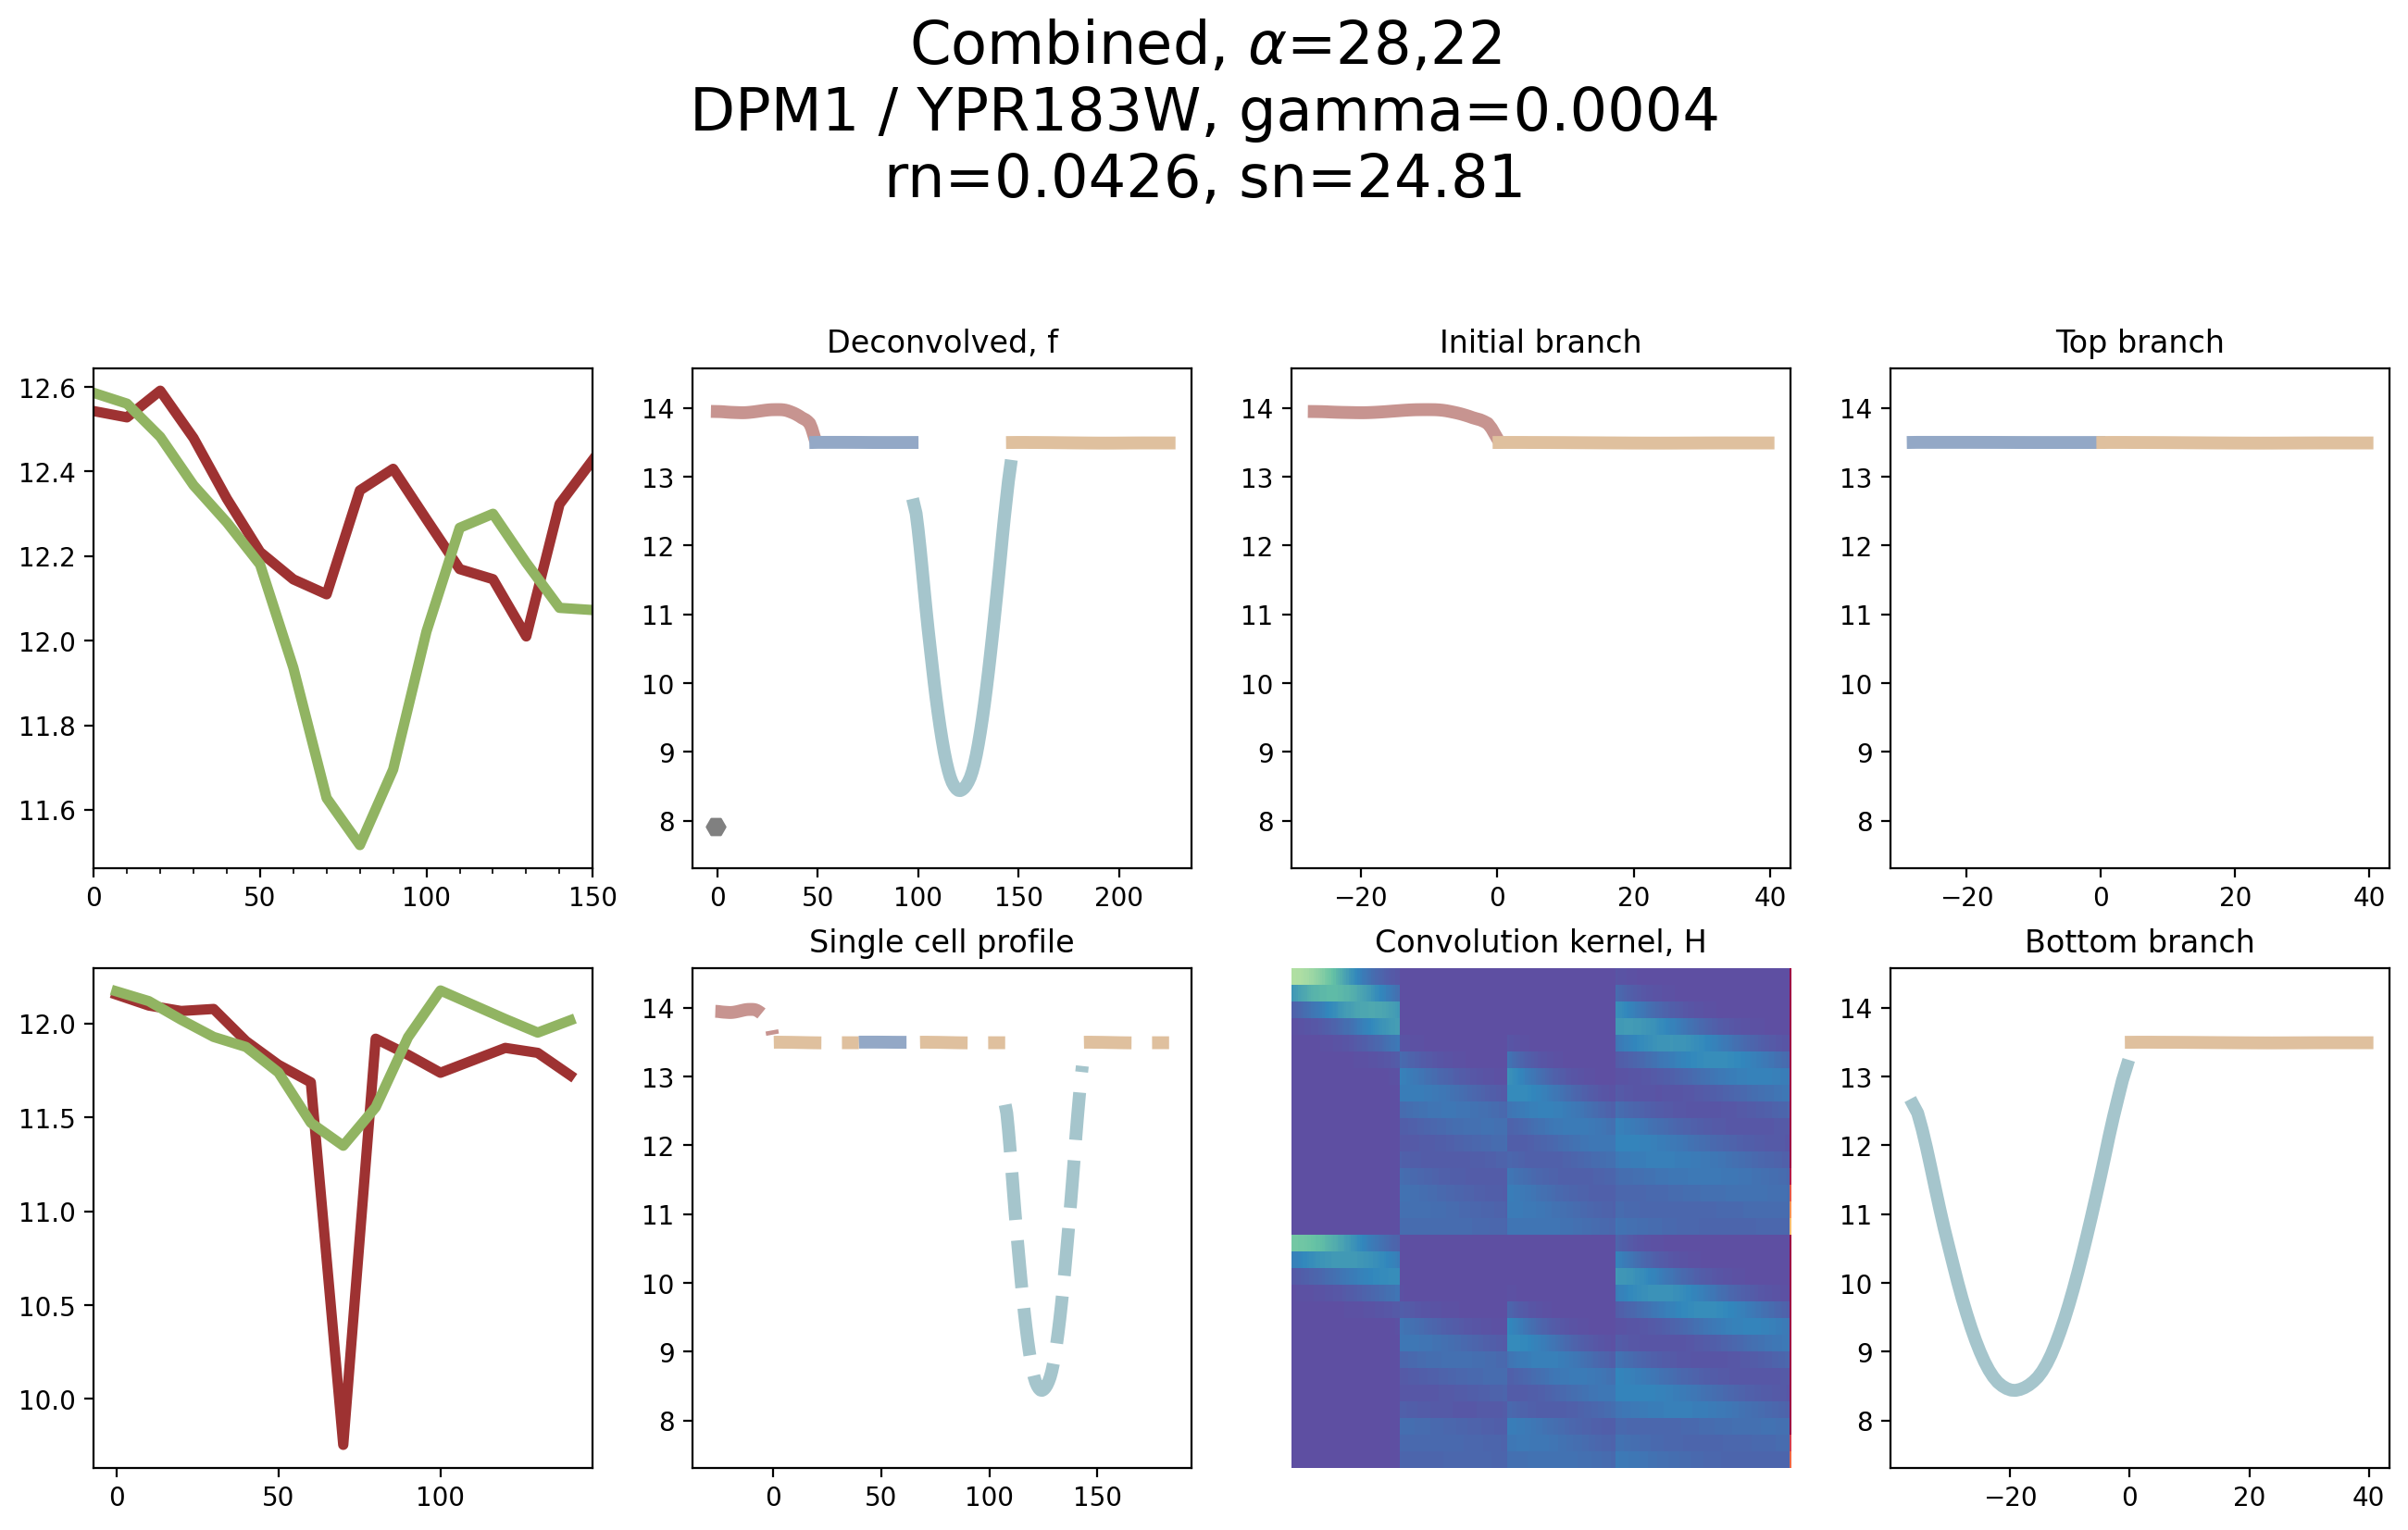

In [211]:
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.model import Model

gene_expression_config = load_combined_yl_alpha_vst_gene_expression_config()
model = Model(gene_expression_config, 'DPM1')
model.deconvolve_find_optimal_gamma()
fig = model.plot_deconvolved_gene()

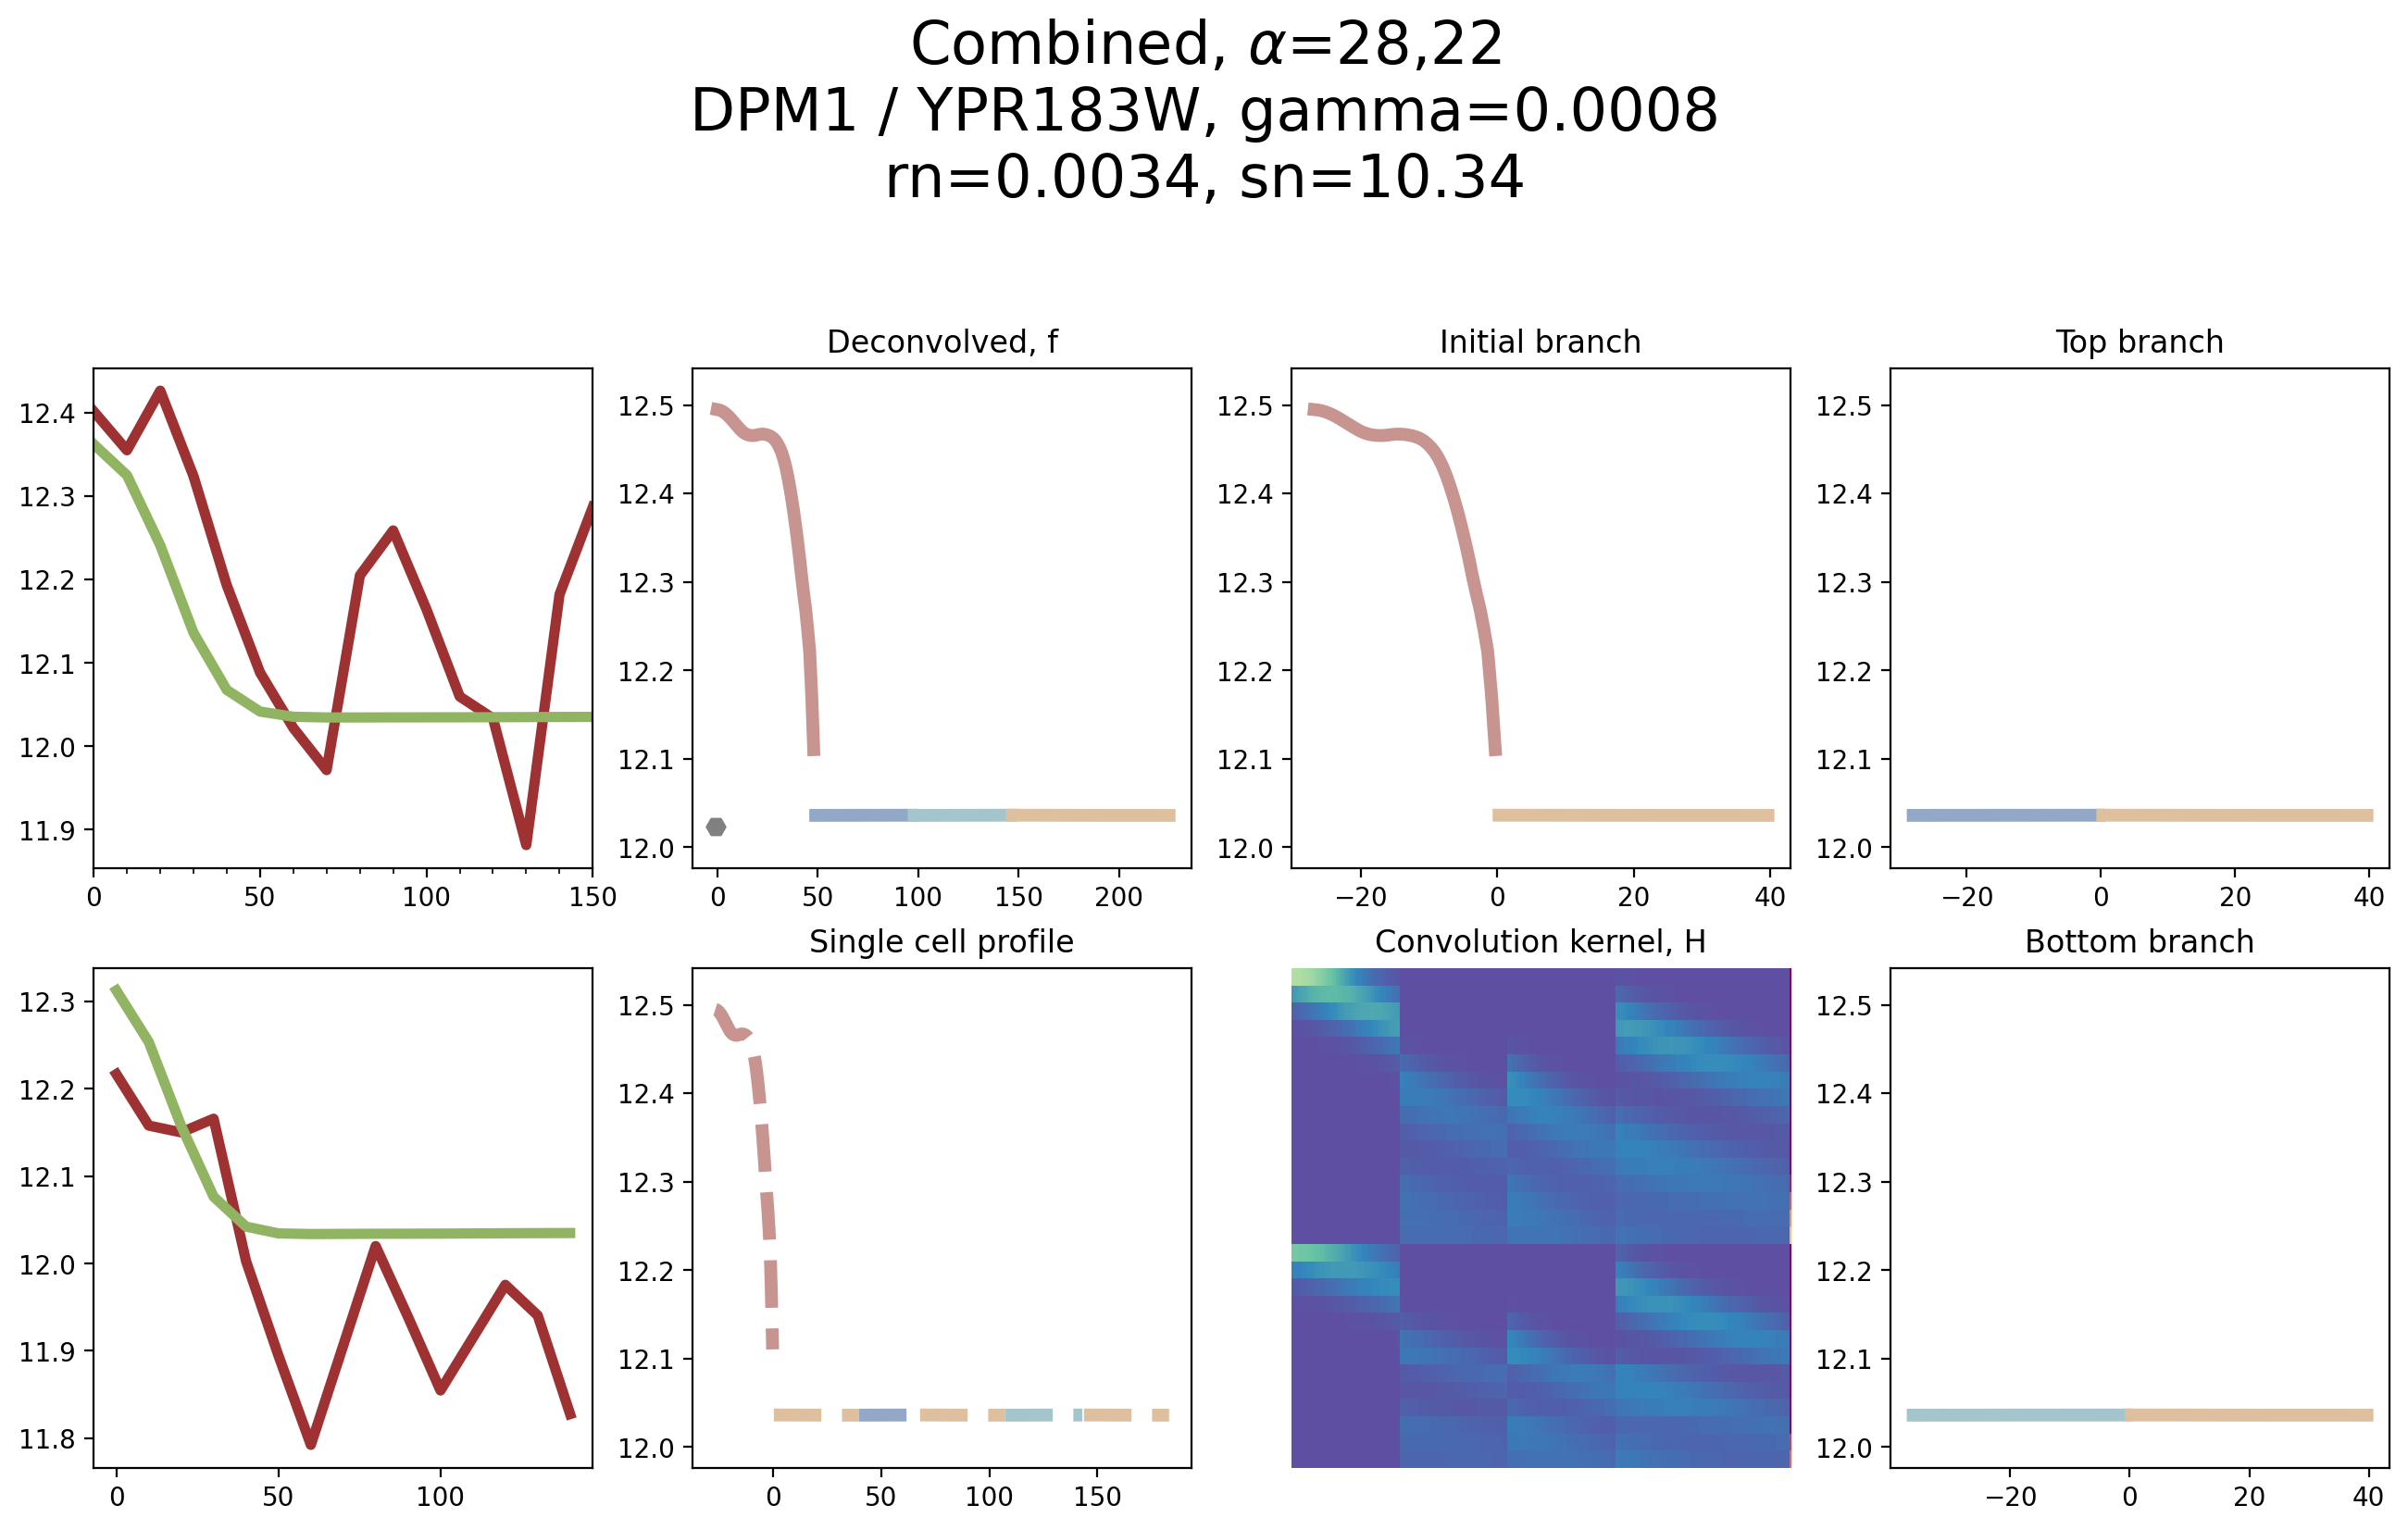

In [214]:
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.model import Model

gene_expression_config = load_combined_yl_alpha_vst_gene_expression_config()
model = Model(gene_expression_config, 'DPM1')
model.deconvolve_find_optimal_gamma()
fig = model.plot_deconvolved_gene()

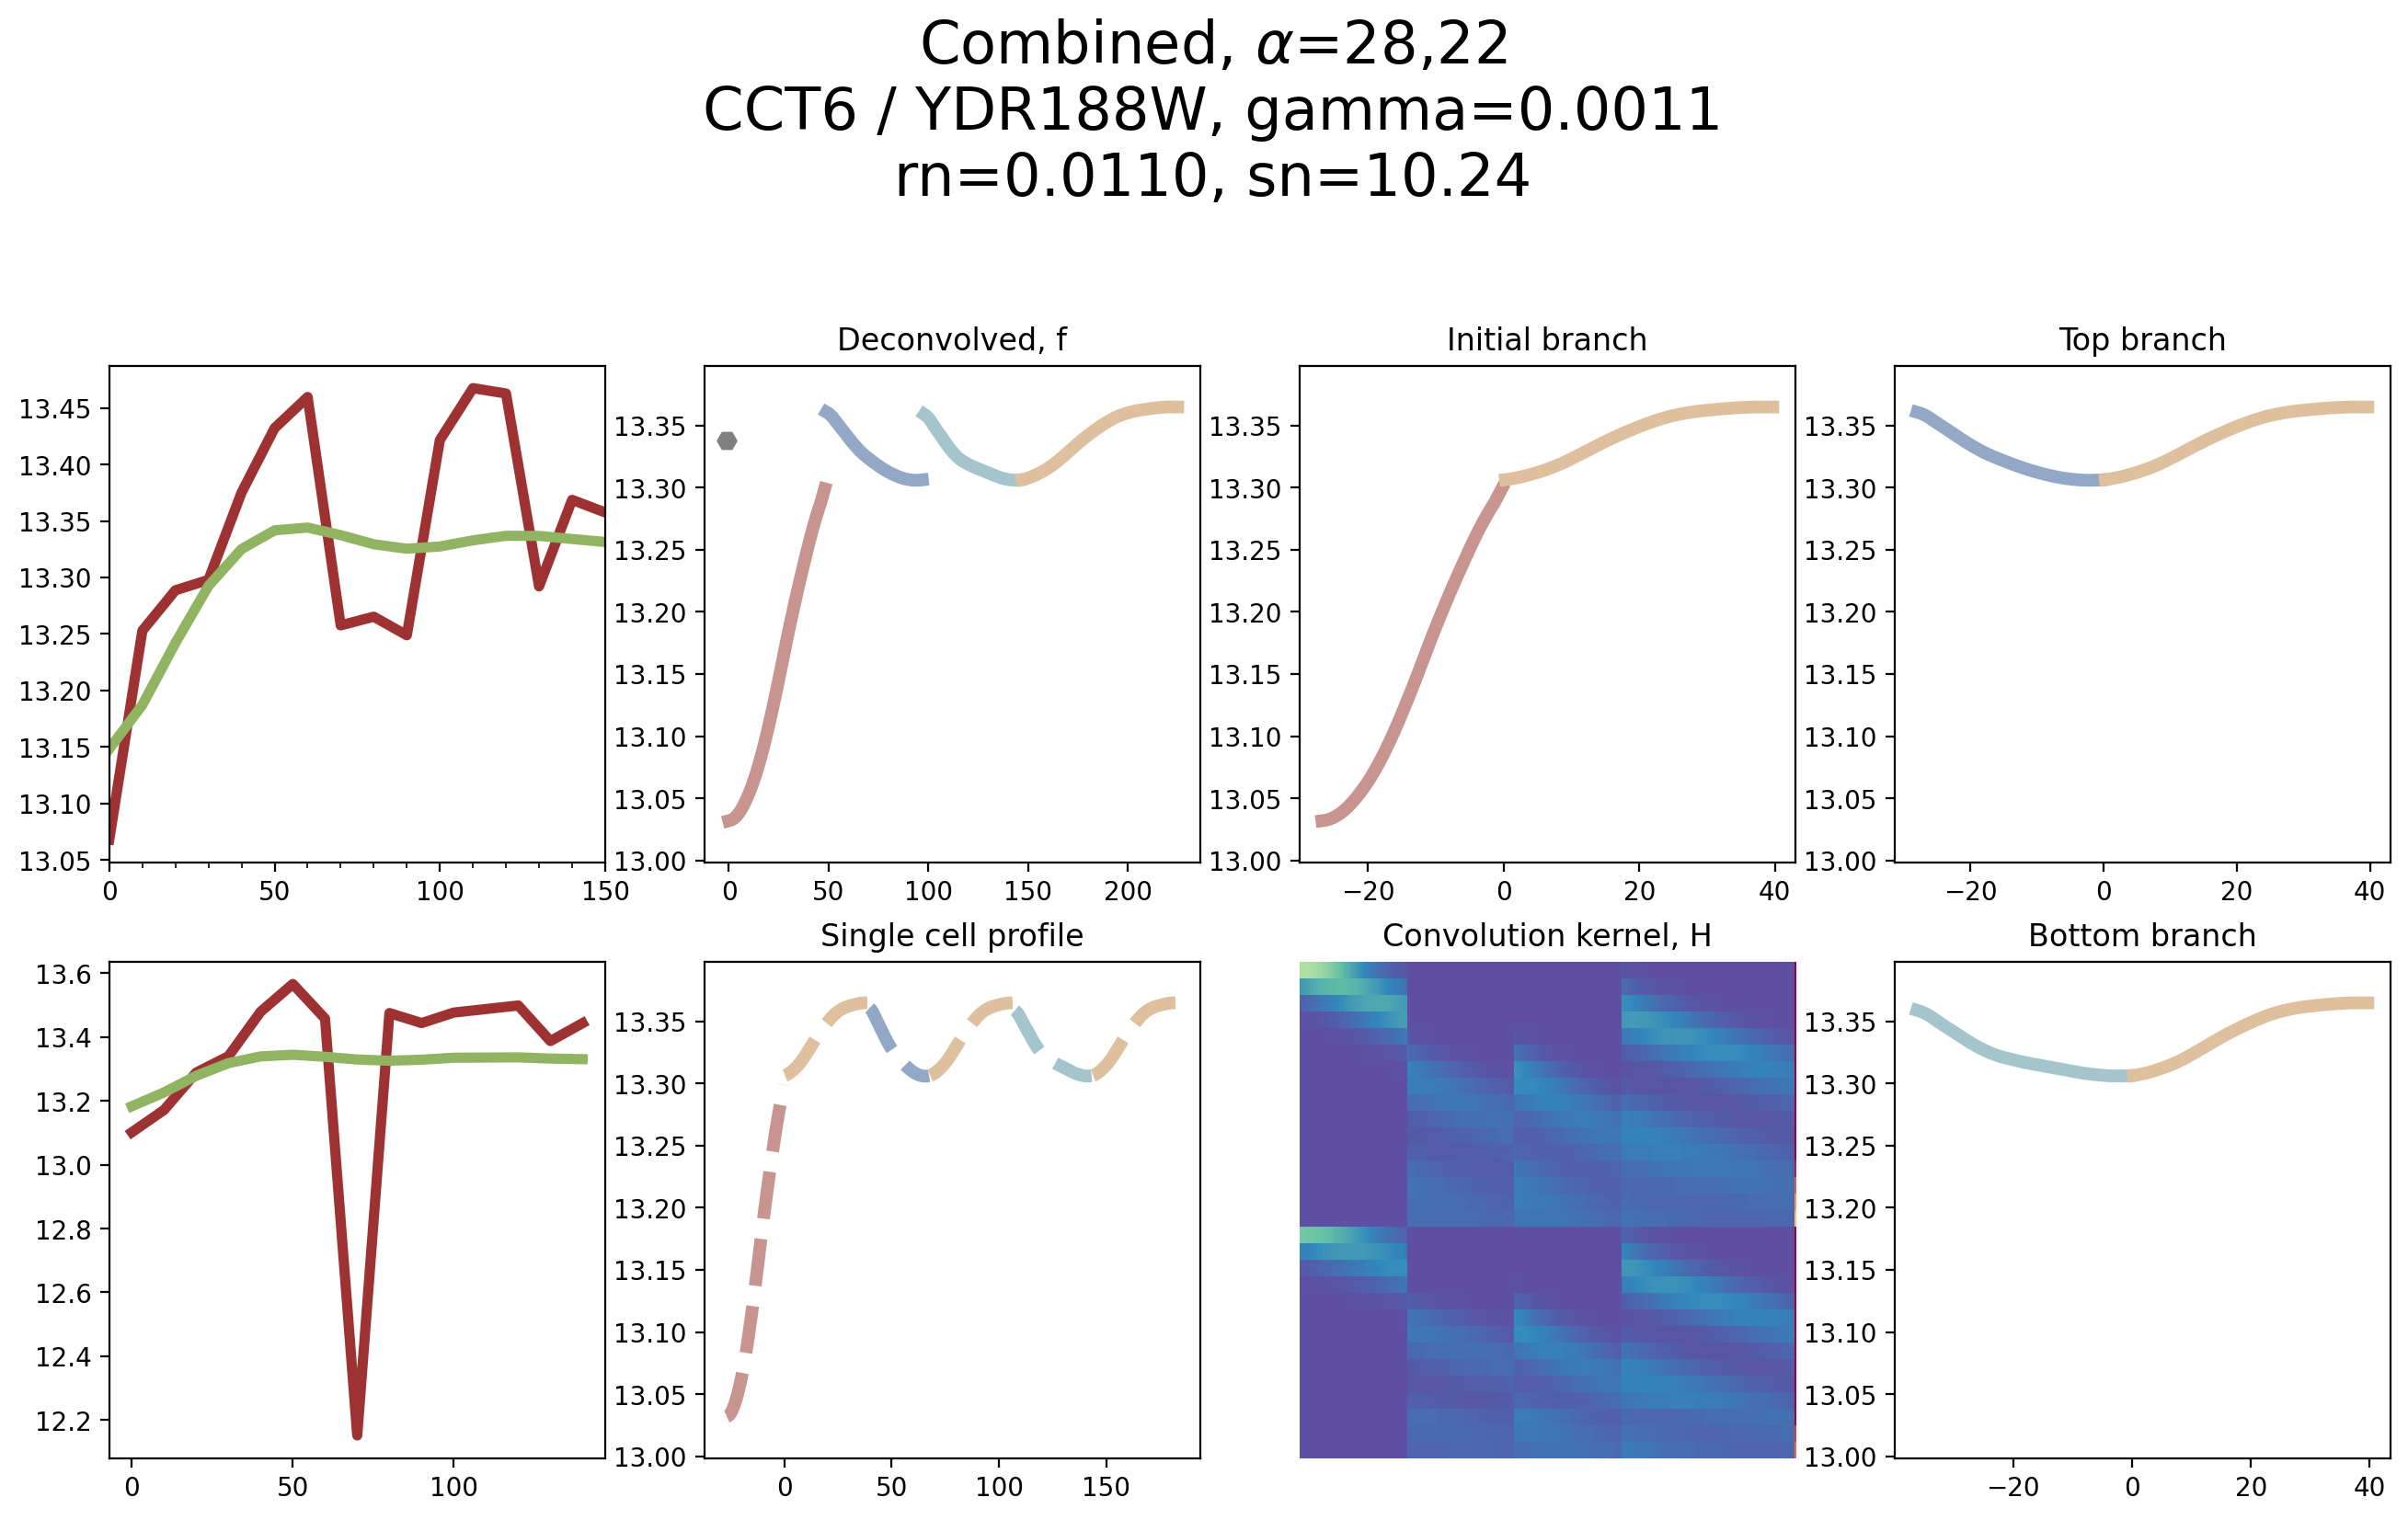

In [221]:
gene_expression_config = load_combined_yl_alpha_vst_gene_expression_config(drop_rep2_70=False)
model = Model(gene_expression_config, 'CCT6')
model.deconvolve_find_optimal_gamma()
fig = model.plot_deconvolved_gene()

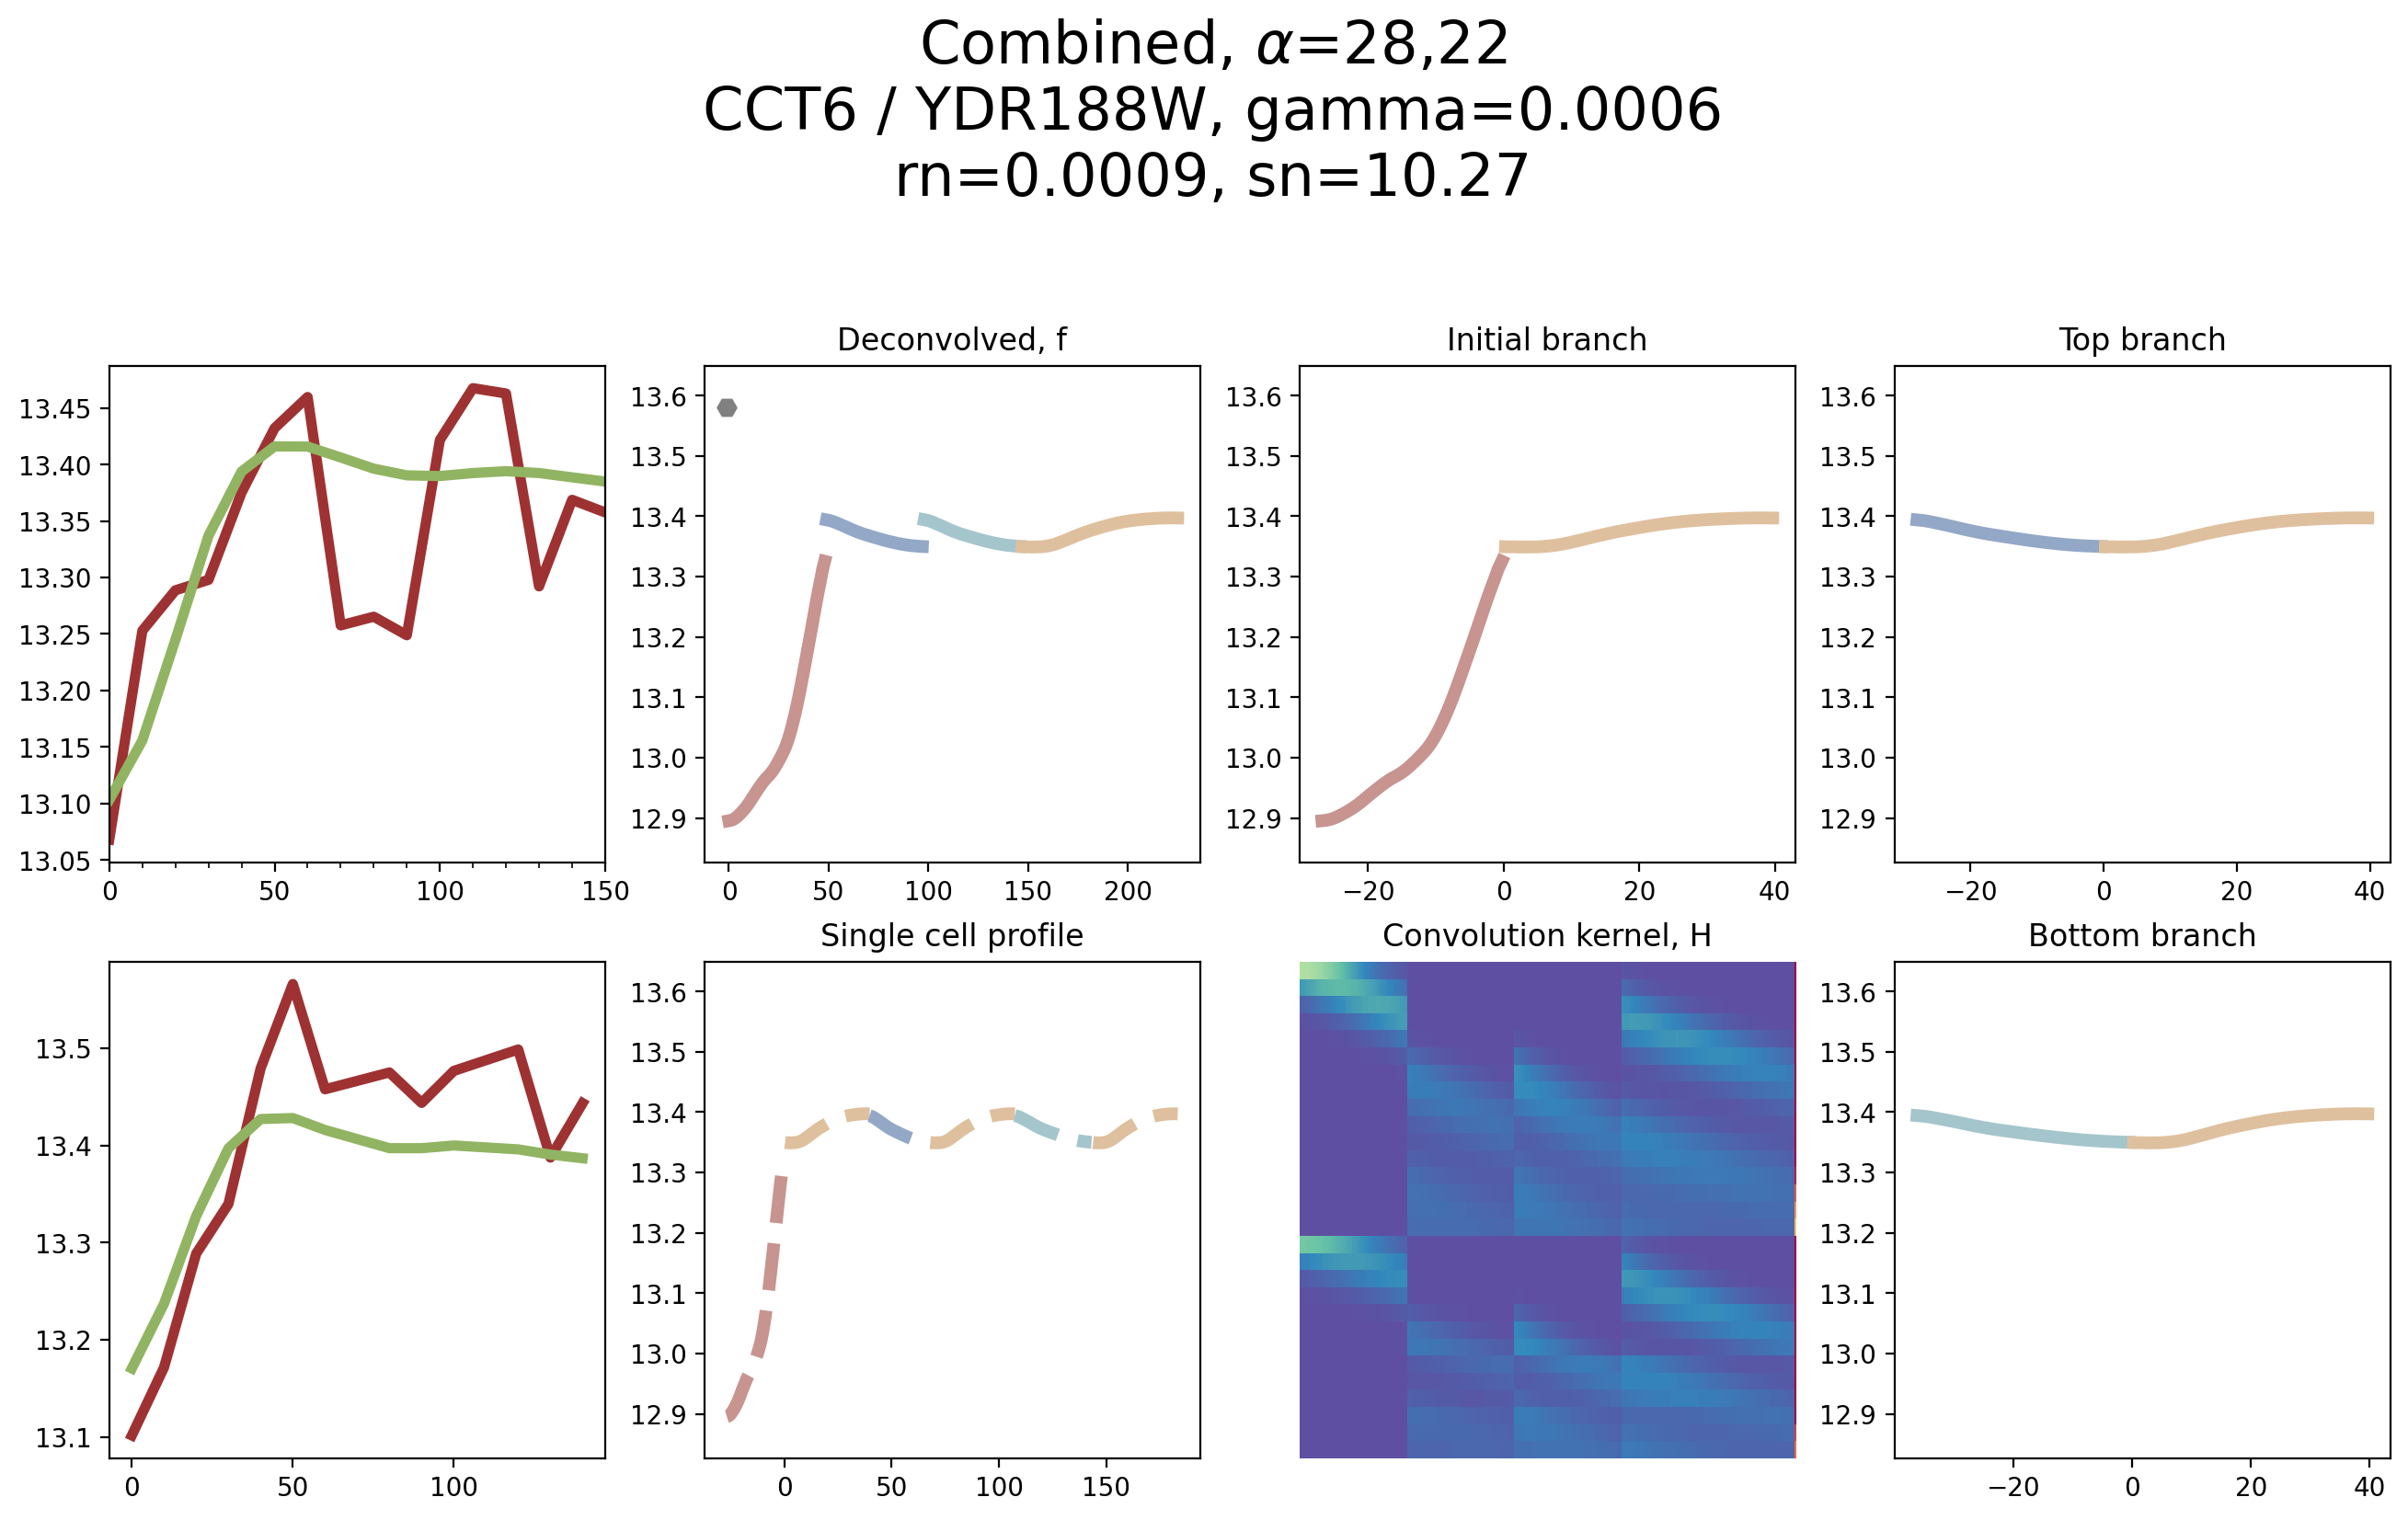

In [222]:
gene_expression_config = load_combined_yl_alpha_vst_gene_expression_config()
model = Model(gene_expression_config, 'CCT6')
model.deconvolve_find_optimal_gamma()
fig = model.plot_deconvolved_gene()

In [205]:
def normalize_wt(wt_dat):
    
    normalized_counts_target = 60000
    
    # Normalize such that each sample is of equivalent sum
    dat = wt_dat.values / wt_dat.values.sum(axis=0).reshape((1, -1)) \
        * normalized_counts_target

    # Next normalize each gene's timecourse such that we can identify if there is an
    # anomolous timepoint in the dynamic range of the gene
    
    gene_means = dat.mean(axis=1)
    gene_stds = dat.std(axis=1)
    
    dat = (dat - gene_means.reshape((-1, 1))) / gene_stds.reshape((-1, 1))
    return dat


Text(0.5, 1.0, 'Replicate 2 normalized RNA-seq reads')

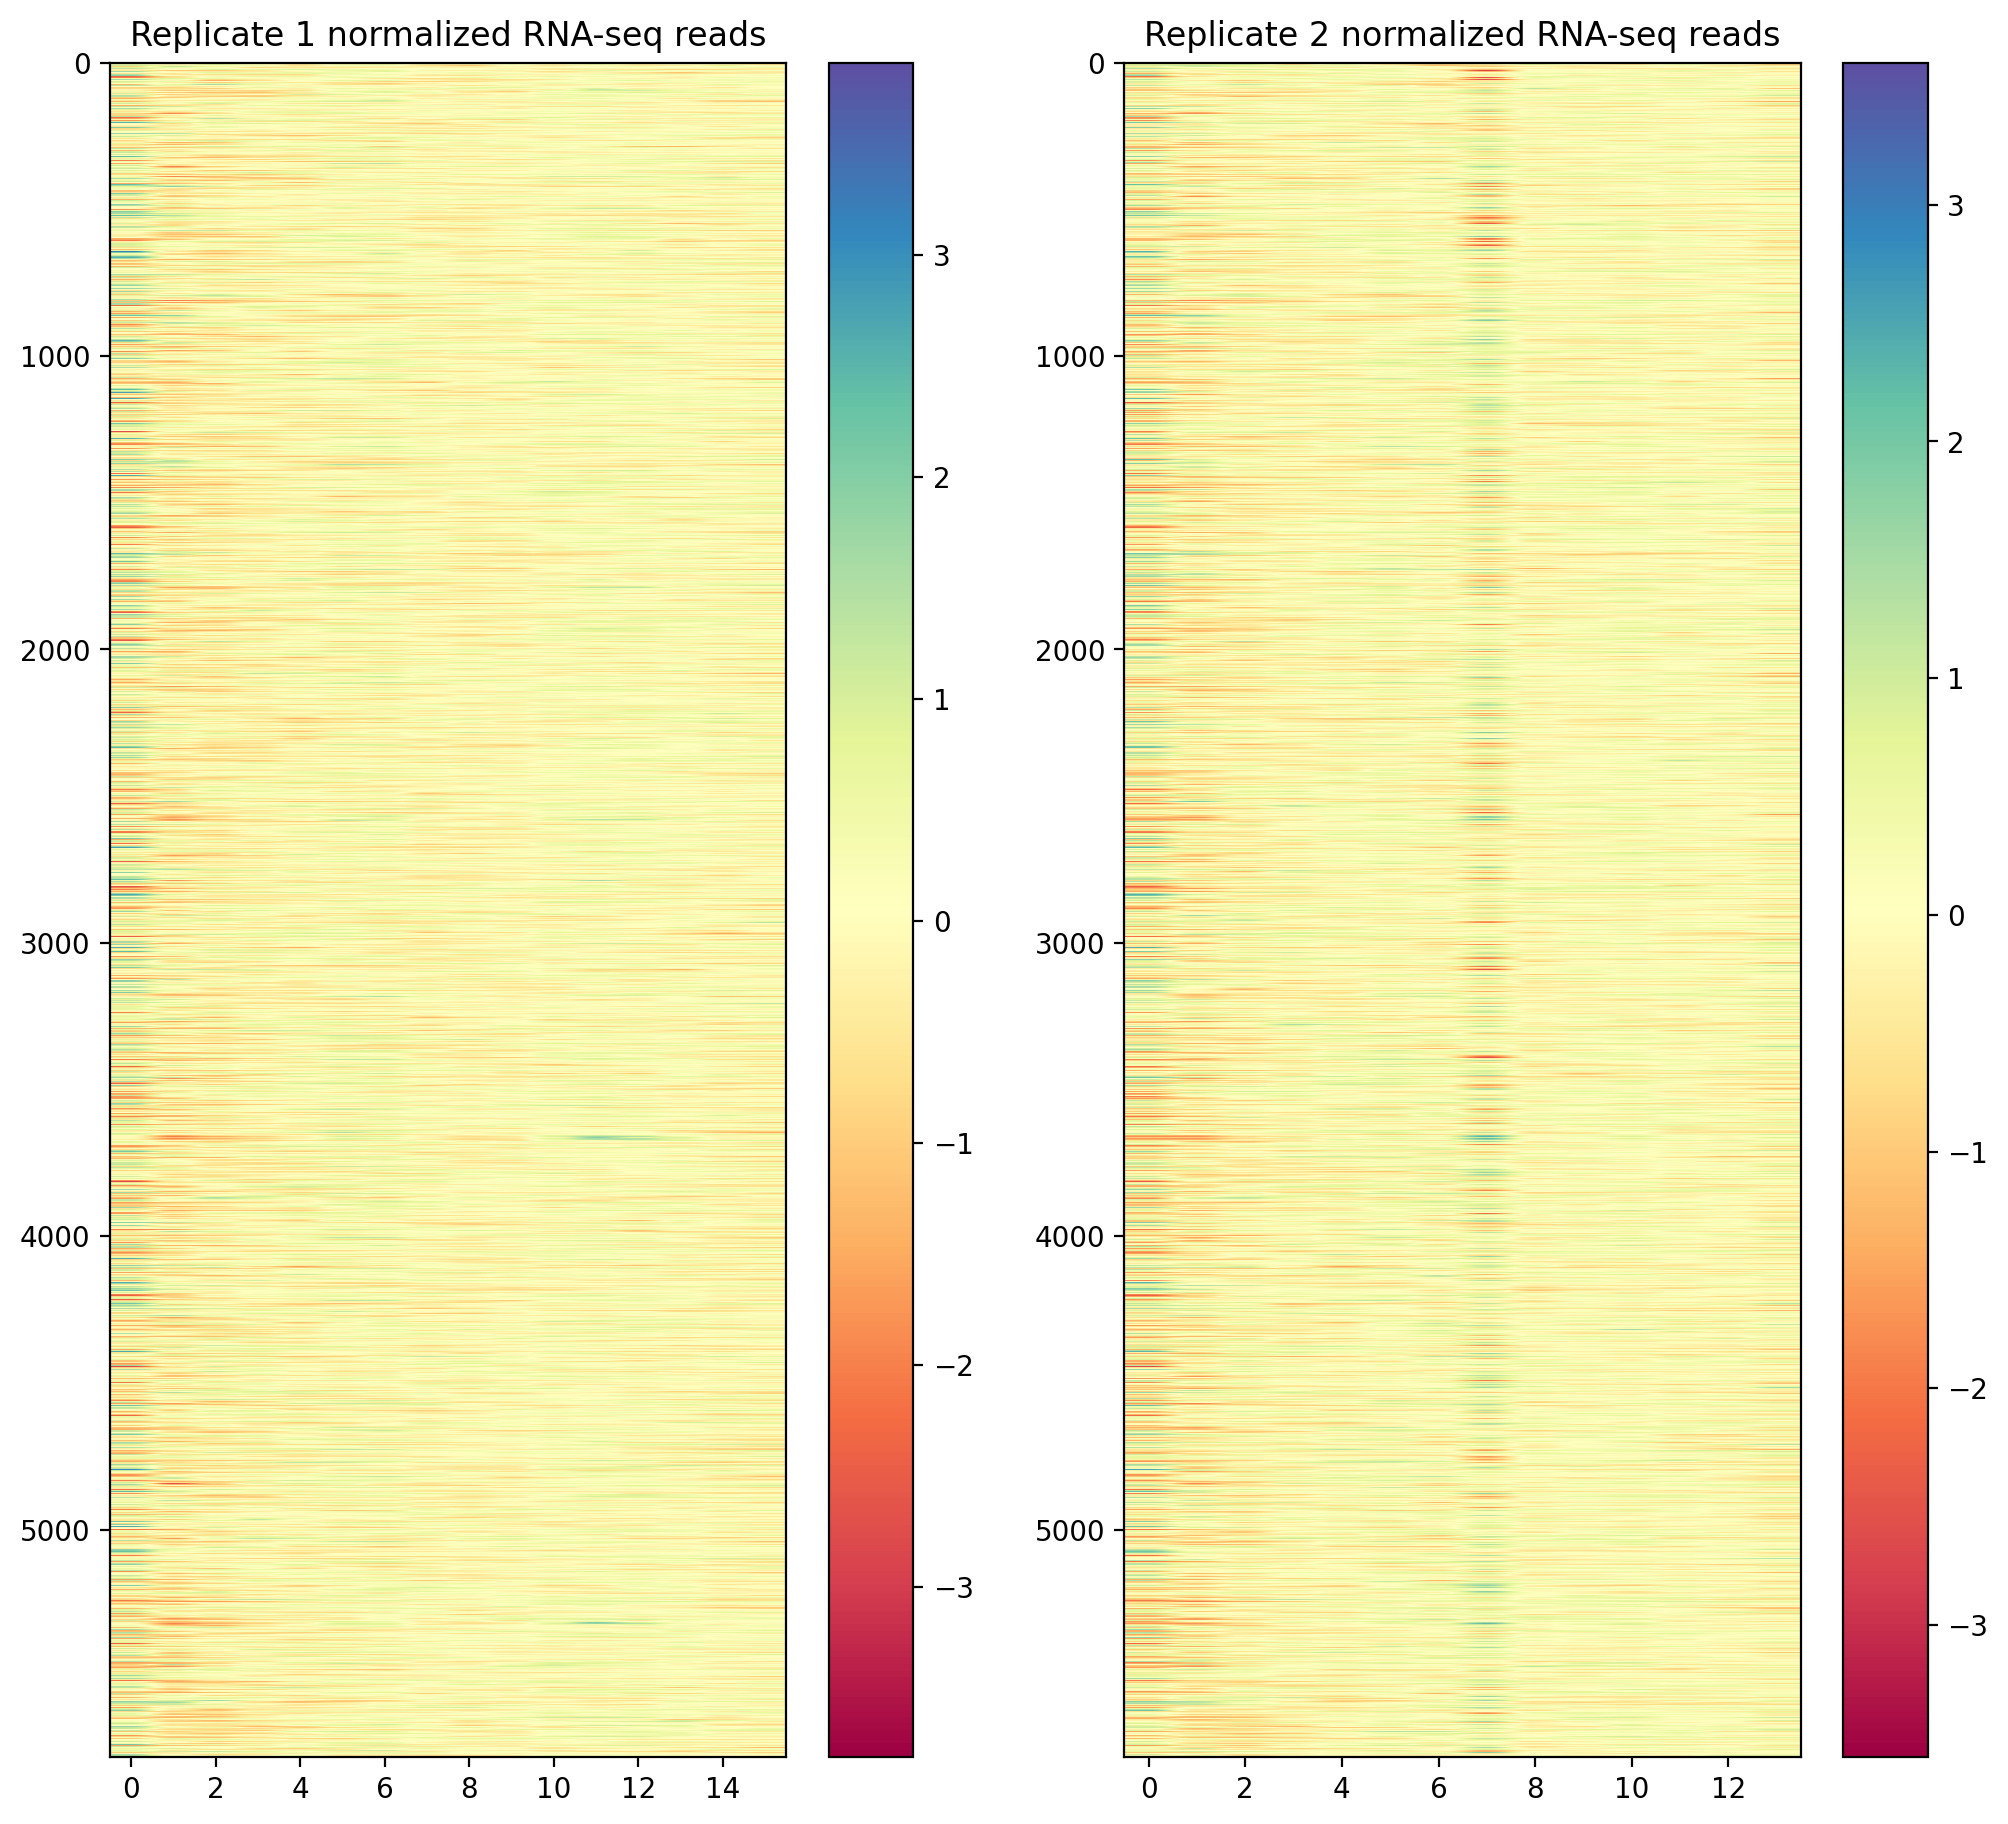

In [208]:
wt_data1 = read_yl_vst_data_rep(1)
dat = normalize_wt(wt_data1)

plt.figure(figsize=(12, 11))
plt.subplot(1, 2, 1)
plt.imshow(dat, aspect='auto', cmap='Spectral')
plt.colorbar()
plt.title("Replicate 1 normalized RNA-seq reads")

plt.subplot(1, 2, 2)
wt_data2 = read_yl_vst_data_rep(2)
dat = normalize_wt(wt_data2)
plt.imshow(dat, aspect='auto', cmap='Spectral')
plt.colorbar()
plt.title("Replicate 2 normalized RNA-seq reads")